In [120]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler


  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [150]:
df = pd.concat([X, y], axis=1)
df.head(20)
#df.isnull().sum()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


In [122]:
df['num'].value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [123]:
# Convert y variable into binary (from int)
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
df.drop(columns=['num'], inplace=True)
df['target'].value_counts()
#df.isnull().sum()

target
0    164
1    139
Name: count, dtype: int64

In [124]:
#Drop all the missing values

df.dropna(inplace=True)
df.isnull().sum()



age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [144]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

categorical_cols = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train_encoded.shape
X_test_encoded.shape

# Check to see patients who fall into the baseline group (cp_1)
X_train_encoded[
    (X_train_encoded['cp_2'] == False) &
    (X_train_encoded['cp_3'] == False) &
    (X_train_encoded['cp_4'] == False)
]

X_train_encoded.head(20)

,age,trestbps,chol,thalach,oldpeak,sex_1,cp_2,cp_3,cp_4,fbs_1,restecg_1,restecg_2,exang_1,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
55,54,124,266,109,2.2,True,False,False,True,False,False,True,True,True,False,True,False,False,False,True
160,46,101,197,156,0.0,True,True,False,False,True,False,False,False,False,False,False,False,False,False,True
178,43,130,315,162,1.9,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False
86,47,138,257,156,0.0,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False
79,58,150,270,111,0.8,True,False,False,True,False,False,True,True,False,False,False,False,False,False,True
208,55,130,262,155,0.0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
111,56,125,249,144,1.2,True,False,False,True,True,False,True,True,True,False,True,False,False,False,False
77,51,140,308,142,1.5,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False
288,56,130,221,163,0.0,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True
47,50,150,243,128,2.6,True,False,False,True,False,False,True,False,True,False,False,False,False,False,True


In [126]:
### Naive Bayes Training
nb1 = GaussianNB()
nb1.fit(X_train_encoded, y_train)
y_pred_nb1 = nb1.predict(X_test_encoded)

nb2 = GaussianNB(var_smoothing=1e-2)
nb2.fit(X_train_encoded, y_train)
y_pred_nb2 = nb2.predict(X_test_encoded)

print("NB default accuracy:", accuracy_score(y_test, y_pred_nb1))
print("NB smoother accuracy:", accuracy_score(y_test, y_pred_nb2))
print(classification_report(y_test, y_pred_nb1))



NB default accuracy: 0.8333333333333334
NB smoother accuracy: 0.75
              precision    recall  f1-score   support

           0       0.81      0.91      0.85        32
           1       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



In [127]:
lr = LinearRegression()
lr.fit(X_train_encoded, y_train)

y_pred_lr_prob = lr.predict(X_test_encoded)
y_pred_lr = (y_pred_lr_prob > 0.5).astype(int)
print("Linear Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Linear Regression accuracy: 0.8166666666666667
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        32
           1       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60



In [128]:
# Lasso Regression (L1)
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_encoded, y_train)

y_pred_lasso = (lasso.predict(X_test_encoded) > 0.5).astype(int)
print("Lasso accuracy:", accuracy_score(y_test, y_pred_lasso))

Lasso accuracy: 0.8


In [129]:
# Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_encoded, y_train)

y_pred_ridge = (ridge.predict(X_test_encoded) > 0.5).astype(int)
print("Ridge accuracy:", accuracy_score(y_test, y_pred_ridge))


Ridge accuracy: 0.8166666666666667


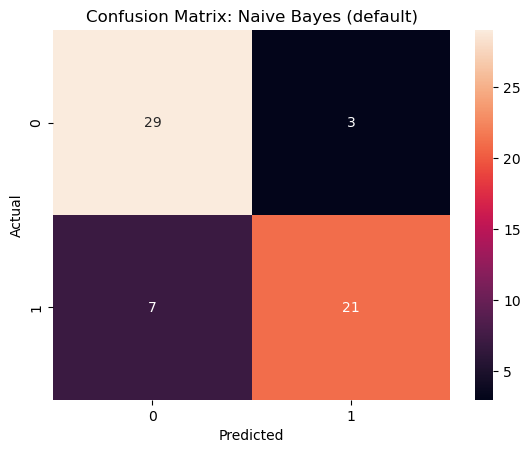

In [151]:
# Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb1)

plt.figure()
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Confusion Matrix: Naive Bayes (default)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

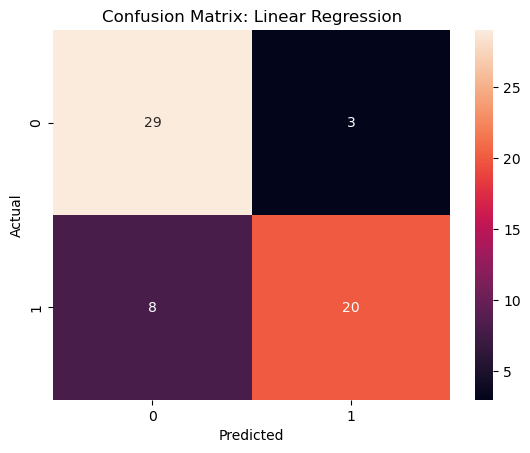

In [152]:
# Linear Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Confusion Matrix: Linear Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

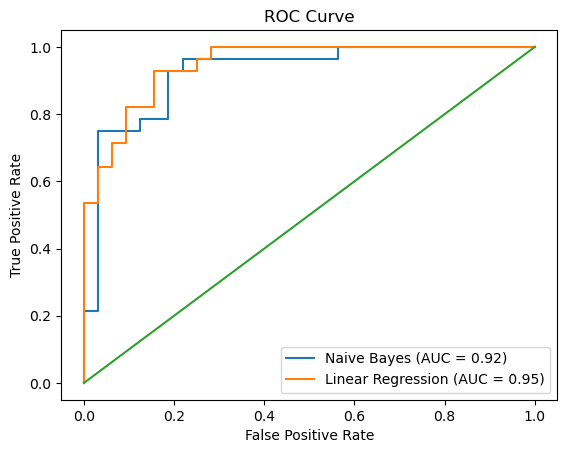

In [132]:
# Naive Bayes ROC
y_prob_nb = nb1.predict_proba(X_test_encoded)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

# Linear Regression ROC
y_prob_lr = lr.predict(X_test_encoded)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()

plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Linear Regression (AUC = {auc_lr:.2f})")

plt.plot([0, 1], [0, 1])  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()